In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# PCA

In [2]:
# This data set contains statistics, in arrests per 100,000 residents for assault,
# murder, and rape in each of the 50 US states in 1973.
# Also given is the percent of the population living in urban areas.
# McNeil, D. R. (1977) Interactive Data Analysis. New York: Wiley.

df = pd.read_csv('USArrests.csv', index_col = 0)
print(df.head())
print(df.describe())

            Murder  Assault  UrbanPop  Rape
Alabama       13.2      236        58  21.2
Alaska        10.0      263        48  44.5
Arizona        8.1      294        80  31.0
Arkansas       8.8      190        50  19.5
California     9.0      276        91  40.6
         Murder     Assault   UrbanPop       Rape
count  50.00000   50.000000  50.000000  50.000000
mean    7.78800  170.760000  65.540000  21.232000
std     4.35551   83.337661  14.474763   9.366385
min     0.80000   45.000000  32.000000   7.300000
25%     4.07500  109.000000  54.500000  15.075000
50%     7.25000  159.000000  66.000000  20.100000
75%    11.25000  249.000000  77.750000  26.175000
max    17.40000  337.000000  91.000000  46.000000


In [3]:
# Standardize the data
scaler = StandardScaler()
df_scaled = scaler.fit_transform(df)
df_scaled

array([[ 1.25517927,  0.79078716, -0.52619514, -0.00345116],
       [ 0.51301858,  1.11805959, -1.22406668,  2.50942392],
       [ 0.07236067,  1.49381682,  1.00912225,  1.05346626],
       [ 0.23470832,  0.23321191, -1.08449238, -0.18679398],
       [ 0.28109336,  1.2756352 ,  1.77678094,  2.08881393],
       [ 0.02597562,  0.40290872,  0.86954794,  1.88390137],
       [-1.04088037, -0.73648418,  0.79976079, -1.09272319],
       [-0.43787481,  0.81502956,  0.45082502, -0.58583422],
       [ 1.76541475,  1.99078607,  1.00912225,  1.1505301 ],
       [ 2.22926518,  0.48775713, -0.38662083,  0.49265293],
       [-0.57702994, -1.51224105,  1.21848371, -0.11129987],
       [-1.20322802, -0.61527217, -0.80534376, -0.75839217],
       [ 0.60578867,  0.94836277,  1.21848371,  0.29852525],
       [-0.13637203, -0.70012057, -0.03768506, -0.0250209 ],
       [-1.29599811, -1.39102904, -0.5959823 , -1.07115345],
       [-0.41468229, -0.67587817,  0.03210209, -0.34856705],
       [ 0.44344101, -0.

In [4]:
# PCA
pca = PCA()
components = pca.fit_transform(df_scaled)

# Create a DataFrame for PCA components
components_df = pd.DataFrame(data = components,
                             columns = [f'PC{i + 1}' for i in range(len(df.columns))],
                             index = df.index)

components_df.head()

,PC1,PC2,PC3,PC4
Alabama,0.985566,1.133392,-0.444269,0.156267
Alaska,1.950138,1.073213,2.040003,-0.438583
Arizona,1.763164,-0.745957,0.054781,-0.834653
Arkansas,-0.141420,1.119797,0.114574,-0.182811
California,2.523980,-1.542934,0.598557,-0.341996


In [5]:
# Variance explained by each component
print("Variance of each component (%):", pca.explained_variance_ratio_ * 100)
print("Total variance explained (%):", sum(pca.explained_variance_ratio_) * 100)

Variance of each component (%): [62.00603948 24.74412881  8.91407951  4.33575219]
Total variance explained (%): 99.99999999999999


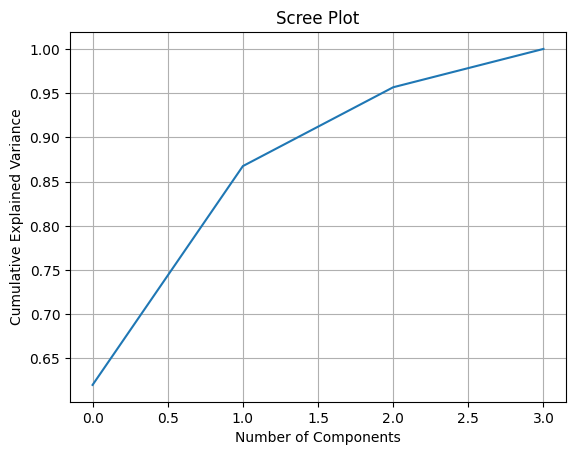

array([0.62006039, 0.86750168, 0.95664248, 1.        ])

In [9]:
# Scree plot
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Scree Plot')
plt.grid(True)
plt.show()

np.cumsum(pca.explained_variance_ratio_)

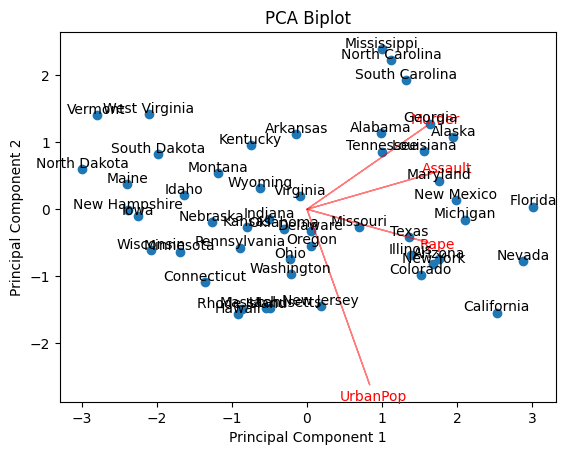

In [11]:
# Biplot (first two principal components)
plt.scatter(components_df['PC1'], components_df['PC2'])
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('PCA Biplot')

# Plot arrows
for i, colname in enumerate(df.columns):
    plt.arrow(0, 0, pca.components_[0, i] * 3, pca.components_[1, i] * 3, color='red', alpha=0.5)
    plt.text(pca.components_[0, i] * 3.2, pca.components_[1, i] * 3.2, colname, color='red', ha='center', va='center')

# State names
for i, txt in enumerate(components_df.index):
    plt.annotate(txt, (components_df['PC1'][i],
                       components_df['PC2'][i]),
                 textcoords = "offset points",
                 xytext=(0,1),
                 ha = 'center')
plt.show()

# Exercice 1 (20 minutes)

Using the 'painters' dataset (subjective ratings of painters), perform a principal component analysis. Are two principal components sufficient to represent this dataset? Draw a scatter plot for the first two principal components using different colors or symbols to distinguish between the schools of painting.

The subjective assessment, on a 0 to 20 integer scale, of 54 classical painters. The painters were assessed on four characteristics: composition, drawing, colour and expression. The data is due to the Eighteenth century art critic, de Piles.

1. A. J. Weekes (1986) A Genstat Primer. Edward Arnold.
2. M. Davenport and G. Studdert-Kennedy (1972) The statistical analysis of aesthetic judgement: an exploration. Applied Statistics 21, 324–333.
3. I. T. Jolliffe (1986) Principal Component Analysis. Springer.

# t-SNE & UMAP

In [12]:
!pip install umap-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 2.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.8/56.8 kB 6.0 MB/s eta 0:00:00


In [13]:
from sklearn.manifold import TSNE
from umap import UMAP
from sklearn.datasets import load_iris

In [16]:
# Load the Iris dataset
data = load_iris()
df = pd.DataFrame(data.data, columns = data.feature_names)
df['Species'] = data.target_names[data.target]
print(df.head())

# Scale the data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df.iloc[:, 0:4])

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  Species  
0  setosa  
1  setosa  
2  setosa  
3  setosa  
4  setosa  


In [17]:
# t-SNE
tsne = TSNE(n_components = 2,
            perplexity = 30,
            n_iter = 600)
tsne_results = tsne.fit_transform(scaled_data)

In [19]:
# UMAP
umap = UMAP()
umap_results = umap.fit_transform(scaled_data)

In [20]:
# PCA
pca = PCA(n_components = 2)
pca_results = pca.fit_transform(scaled_data)

In [21]:
# Convert results to DataFrame
tsne_df = pd.DataFrame(tsne_results, columns = ['X', 'Y'])
tsne_df['Method'] = 'tSNE'
pca_df = pd.DataFrame(pca_results, columns = ['X', 'Y'])
pca_df['Method'] = 'PCA'
umap_df = pd.DataFrame(umap_results, columns = ['X', 'Y'])
umap_df['Method'] = 'UMAP'

# Combine all results
results_df = pd.concat([tsne_df, pca_df, umap_df], axis = 0)
results_df['Species'] = pd.concat([df['Species']]*3, ignore_index = True)

results_df.head()

,X,Y,Method,Species
0,-21.823456,-0.841164,tSNE,setosa
1,-18.112484,-1.645957,tSNE,setosa
2,-19.076565,-0.631151,tSNE,setosa
3,-18.331631,-0.594459,tSNE,setosa
4,-22.281572,-0.259920,tSNE,setosa


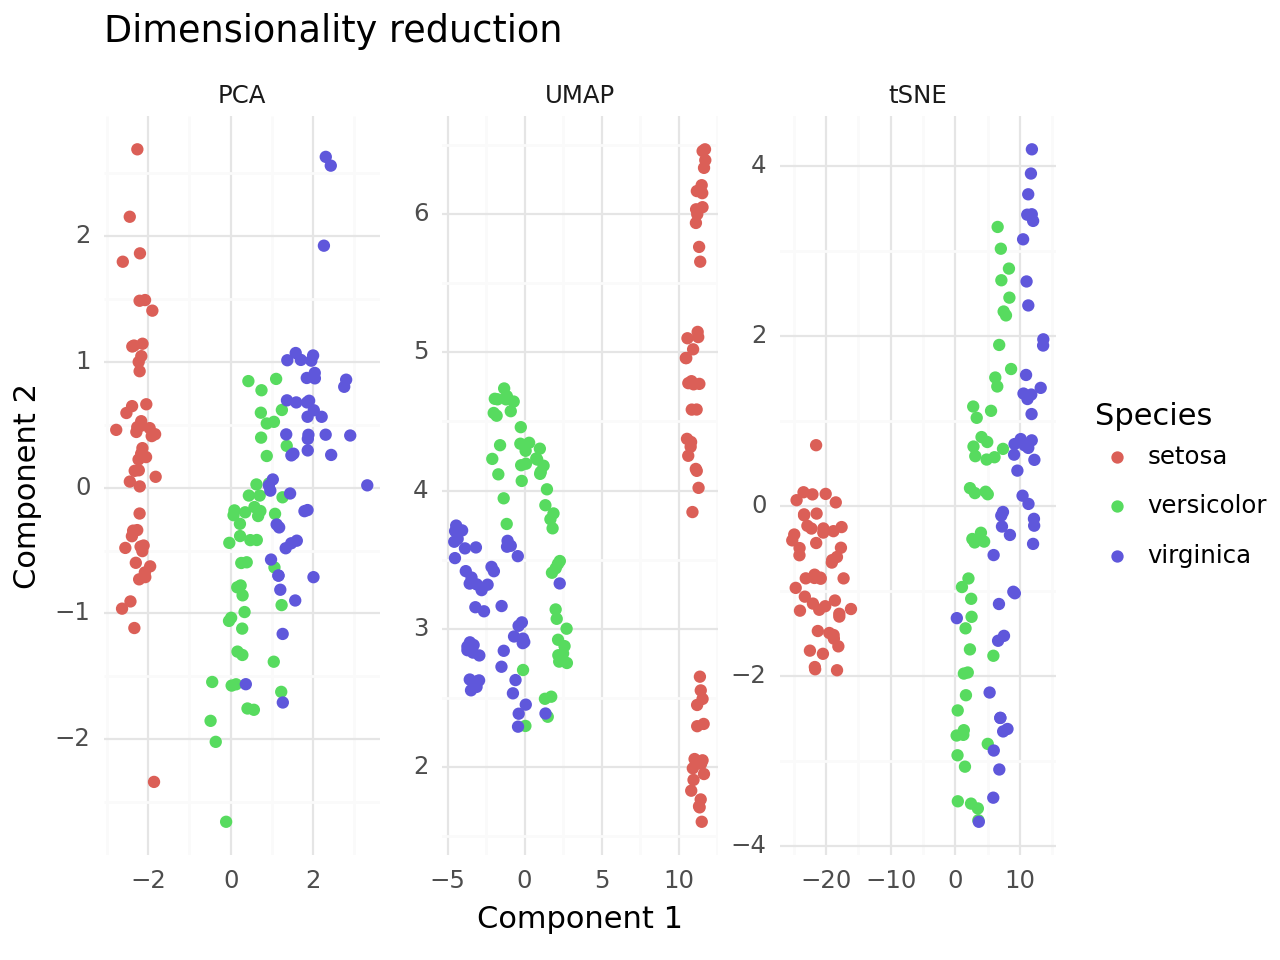

<Figure Size: (640 x 480)>

In [22]:
# Plot
from plotnine import ggplot, aes, geom_point, geom_text, labs, theme_minimal, facet_wrap

(
    ggplot(results_df, aes(x = 'X', y = 'Y', color = 'Species'))
    +geom_point()
    +labs(title = 'Dimensionality reduction',
         x = 'Component 1',
         y = 'Component 2')
    +facet_wrap('Method', scales = 'free')
    +theme_minimal()
)

# Multidimensional Scaling

In [23]:
df = pd.read_csv('eurodist.csv', index_col = 0)

# The eurodist gives the road distances (in km) between 21 cities in Europe.
# The data are taken from a table in The Cambridge Encyclopaedia.
# Crystal, D. Ed. (1990) The Cambridge Encyclopaedia. Cambridge: Cambridge University Press,

df.index.names = ['City']
df.head()

,Athens,Barcelona,Brussels,Calais,Cherbourg,Cologne,Copenhagen,Geneva,Gibraltar,Hamburg,...,Lisbon,Lyons,Madrid,Marseilles,Milan,Munich,Paris,Rome,Stockholm,Vienna
City,,,,,,,,,,,,,,,,,,,,,
Athens,0,3313,2963,3175,3339,2762,3276,2610,4485,2977,...,4532,2753,3949,2865,2282,2179,3000,817,3927,1991
Barcelona,3313,0,1318,1326,1294,1498,2218,803,1172,2018,...,1305,645,636,521,1014,1365,1033,1460,2868,1802
Brussels,2963,1318,0,204,583,206,966,677,2256,597,...,2084,690,1558,1011,925,747,285,1511,1616,1175
Calais,3175,1326,204,0,460,409,1136,747,2224,714,...,2052,739,1550,1059,1077,977,280,1662,1786,1381
Cherbourg,3339,1294,583,460,0,785,1545,853,2047,1115,...,1827,789,1347,1101,1209,1160,340,1794,2196,1588


In [24]:
from sklearn.manifold import MDS
# Classical Multidimensional Scaling
mds = MDS(n_components = 2,
          dissimilarity = 'precomputed')
mds_coords = mds.fit_transform(df);

/usr/local/lib/python3.10/dist-packages/sklearn/manifold/_mds.py:299: FutureWarning: The default value of `normalized_stress` will change to `'auto'` in version 1.4. To suppress this warning, manually set the value of `normalized_stress`.


In [25]:
# Convert MDS results into a DataFrame
df_mds = pd.DataFrame(mds_coords,
                  columns = ['V1', 'V2'],
                  index = df.index).reset_index()
print(df_mds)

               City           V1           V2
0            Athens  2755.847457   -85.484572
1         Barcelona  -232.743681  -961.578077
2          Brussels  -205.998857   354.858903
3            Calais  -399.955079   316.283977
4         Cherbourg  -668.231122    78.927924
5           Cologne   -64.966838   558.774421
6        Copenhagen  -135.958738  1263.601761
7            Geneva   176.159370  -259.147122
8         Gibraltar -1110.642029 -1765.111363
9           Hamburg   -12.693891   942.379871
10  Hook of Holland  -249.945637   577.465310
11           Lisbon -1469.320154 -1273.198984
12            Lyons   -15.203044  -273.570012
13           Madrid  -898.540758 -1116.603898
14       Marseilles    80.821596  -578.088247
15            Milan   488.345059  -182.704658
16           Munich   508.984844   286.129048
17            Paris  -281.117213    85.337742
18             Rome  1159.859702  -383.868677
19        Stockholm  -351.418669  1938.536705
20           Vienna   926.717683  

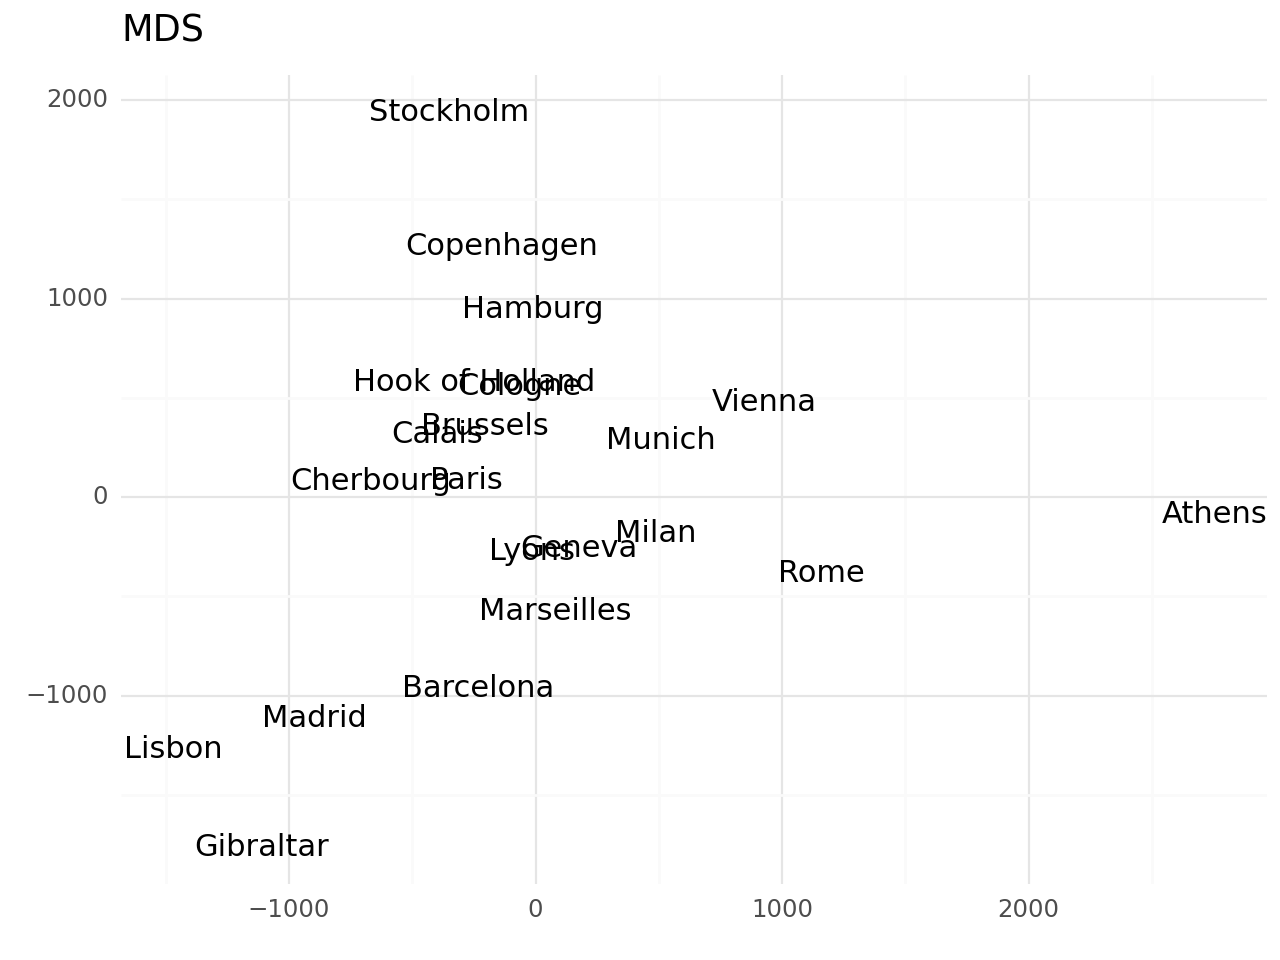

<Figure Size: (640 x 480)>

In [28]:
df_mds['V1'] = -df_mds['V1']
df_mds['V2'] = -df_mds['V2']

# Plot
(
    ggplot(df_mds, aes(x = 'V1', y = 'V2', label = 'City'))
    +geom_text()
    +labs(title = 'MDS',
         x = '',
         y = '')
    +theme_minimal()
)

# Correspondence Analysis

In [29]:
# Load the dataset
df = pd.read_csv('caith.csv', index_col = 0)

# Data on the cross-classification of people in Caithness, Scotland, by eye and hair colour.
# The region of the UK is particularly interesting as there is a mixture of people of Nordic,
# Celtic and Anglo-Saxon origin.
# Fisher, R.A. (1940) The precision of discriminant functions. Annals of Eugenics (London) 10, 422–429.
# Venables, W. N. and Ripley, B. D. (2002) Modern Applied Statistics with S. Fourth edition. Springer.

df.index.names = ['Eye color']
print(df)

           fair  red  medium  dark  black
Eye color                                
blue        326   38     241   110      3
light       688  116     584   188      4
medium      343   84     909   412     26
dark         98   48     403   681     85


In [30]:
from scipy.stats import chi2_contingency

chi2, p_value, _, _ = chi2_contingency(df)

# chi-squared test
print(f"chi2: {np.round(chi2, 3)}, p_value: {np.round(p_value)}")

chi2: 1240.039, p_value: 0.0


In [31]:
! pip install prince

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 415.6/415.6 kB 6.0 MB/s eta 0:00:00


In [32]:
import prince  # for correspondence analysis

# Initialize and fit the correspondence analysis model
ca = prince.CA(n_components = 2)
ca.fit(df);

In [33]:
# Summary of the correspondence analysis eigenvalues
ca.eigenvalues_summary

,eigenvalue,% of variance,% of variance (cumulative)
component,,,
0,0.199,86.56%,86.56%
1,0.030,13.07%,99.63%


In [34]:
ca.row_contributions_.head().style.format('{:.0%}')

,0,1
blue,11%,12%
light,29%,8%
medium,0%,66%
dark,61%,15%


In [35]:
ca.column_contributions_.head().style.format('{:.0%}')

,0,1
fair,40%,27%
red,1%,0%
medium,0%,57%
dark,45%,9%
black,13%,6%


In [36]:
# Plot the correspondence analysis results
ca.plot(
    df,
    x_component = 0,
    y_component = 1,
    show_row_markers = True,
    show_column_markers = True,
    show_row_labels = True,
    show_column_labels = True
)

alt.LayerChart(...)

# Exercice 2 (15 minutes)

Data set 'swiss' contains standardized fertility measure and socio-economic indicators for each of 47 French-speaking provinces of Switzerland at about 1888. Perform metric multidimensional scaling on this dataset and visualize the results.

Becker, R. A., Chambers, J. M. and Wilks, A. R. (1988) The New S Language. Wadsworth & Brooks/Cole.
